In [18]:
import gc
import torch

# Limpiar todo de la GPU
gc.collect()
torch.cuda.empty_cache()

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AlbertTokenizer, AlbertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from tqdm import tqdm

# -------------------------
# Configuration
# -------------------------
CSV_FILE = "IMDBDataset10M.csv"

TOTAL_SAMPLES = 10000  # 10000: Whole data set (Use 1000 to start)
VAL_SIZE = 0.15
TEST_SIZE = 0.15

MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 5
LR = 0.00001
PATIENCE = 2

FINE_TUNE_BERT = False    # <<< False = frozen BERT ; True = Fine Tuning BERT

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Dataset
# -------------------------
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# -------------------------
# Model
# -------------------------
class AlbertClassifier(nn.Module):
    def __init__(self, fine_tune=True):
        super().__init__()
        self.albert = AlbertModel.from_pretrained("albert-base-v2")
        self.classifier = nn.Linear(self.albert.config.hidden_size, 2)

        if not fine_tune:
            for param in self.albert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.albert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0]
        return self.classifier(cls_output)

# -------------------------
# Load CSV Data
# -------------------------
def load_csv_data(path):
    df = pd.read_csv(
        path,
        header=None,
        names=["review", "label"],
        quotechar='"',
        escapechar='\\',
        engine="python"
    )

    df = df.dropna()

    df["label"] = df["label"].str.strip().str.lower()
    label_map = {"negative": 0, "positive": 1}
    df["label"] = df["label"].map(label_map)

    df = df.dropna()

    texts = df["review"].astype(str).tolist()
    labels = df["label"].astype(int).tolist()

    return texts, labels

# -------------------------
# Load and Subsample Data
# -------------------------
texts, labels = load_csv_data(CSV_FILE)
print(f"Loaded {len(texts)} samples (full dataset)")

if TOTAL_SAMPLES is not None and TOTAL_SAMPLES < len(texts):
    df_subset = pd.DataFrame({"text": texts, "label": labels}).sample(
        n=TOTAL_SAMPLES,
        random_state=42
    )
    texts = df_subset["text"].tolist()
    labels = df_subset["label"].tolist()
    print(f"Using {len(texts)} samples after subsampling")

# -------------------------
# Train / Val / Test Split
# -------------------------
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    texts,
    labels,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=labels
)

# Second split: separate validation from training
val_ratio = VAL_SIZE / (1 - TEST_SIZE)  # Adjust ratio for remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio,
    random_state=42,
    stratify=y_temp
)

print(f"Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# -------------------------
# Tokenizer & Dataloaders
# -------------------------
tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")

train_dataset = TextDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = TextDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = TextDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# -------------------------
# Training Setup
# -------------------------
model = AlbertClassifier(fine_tune=FINE_TUNE_BERT).to(DEVICE)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

criterion = nn.CrossEntropyLoss()

# -------------------------
# Training Loop with Progress Bars
# -------------------------
def train_epoch(model, loader, epoch):
    model.train()
    total_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch} [Training]",
        leave=False
    )

    for batch in progress:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

def evaluate(model, loader, desc="Evaluating"):
    model.eval()
    preds, gold = [], []

    progress = tqdm(
        loader,
        desc=desc,
        leave=False
    )

    with torch.no_grad():
        for batch in progress:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids, attention_mask)
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    return accuracy_score(gold, preds)

# -------------------------
# Run Training
# -------------------------
import time
from sklearn.metrics import classification_report, precision_recall_fscore_support
import os

train_start_time = time.time()
history = {"epoch": [], "train_loss": [], "val_acc": []}

# Early stopping variables
best_val_acc = 0.0
epochs_without_improvement = 0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, epoch)
    val_acc = evaluate(model, val_loader, desc=f"Epoch {epoch} [Validation]")
    
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val accuracy: {val_acc:.4f}")

    # Early stopping check (based on validation accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best validation accuracy!")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement ({epochs_without_improvement}/{PATIENCE})")
    
    if epochs_without_improvement >= PATIENCE:
        print(f"\n⚠️ Early stopping triggered after {epoch} epochs (no improvement for {PATIENCE} epochs)")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✓ Restored best model (val accuracy: {best_val_acc:.4f})")

train_end_time = time.time()
training_time = train_end_time - train_start_time

print(f"\nTraining finished in {training_time:.1f} seconds ({training_time/60:.1f} minutes)")
print(f"Fine-tuning enabled: {FINE_TUNE_BERT}")
print(f"Total samples used: {len(texts)}")

# -------------------------
# Final Evaluation on TEST set (unseen during training)
# -------------------------
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)
print("(Test set was NOT used for early stopping)")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["label"].to(DEVICE)
        
        logits = model(input_ids, attention_mask)
        predictions = torch.argmax(logits, dim=1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

final_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

print(f"\nTest Accuracy: {final_accuracy*100:.2f}%")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# -------------------------
# Save Results to CSV
# -------------------------
mode_name = "albert_finetuned" if FINE_TUNE_BERT else "albert_frozen"

actual_epochs = len(history["epoch"])  # Real epochs trained (may be less due to early stopping)

results = {
    'model_type': mode_name,
    'test_accuracy': final_accuracy * 100,
    'val_accuracy': best_val_acc * 100,
    'negative_precision': precision[0] * 100,
    'negative_recall': recall[0] * 100,
    'negative_f1': f1[0] * 100,
    'positive_precision': precision[1] * 100,
    'positive_recall': recall[1] * 100,
    'positive_f1': f1[1] * 100,
    'training_time_sec': training_time,
    'epochs_trained': actual_epochs,
    'epochs_max': EPOCHS,
    'patience': PATIENCE,
    'total_samples': len(texts),
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'max_len': MAX_LEN
}

results_file = './albert_results.csv'
results_df = pd.DataFrame([results])

if os.path.exists(results_file):
    existing_df = pd.read_csv(results_file)
    # Replace if same model_type exists
    existing_df = existing_df[existing_df['model_type'] != mode_name]
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)
print(f"\nResults saved to {results_file}")


Loaded 10000 samples (full dataset)
Split: Train=7000, Val=1500, Test=1500


Epoch 1/5
  Train loss: 0.8185
  Val accuracy: 0.4927
  ✓ New best validation accuracy!


Epoch 2/5
  Train loss: 0.7189
  Val accuracy: 0.5467
  ✓ New best validation accuracy!


Epoch 3/5
  Train loss: 0.6796
  Val accuracy: 0.6107
  ✓ New best validation accuracy!


Epoch 4/5
  Train loss: 0.6468
  Val accuracy: 0.6727
  ✓ New best validation accuracy!


Epoch 5/5
  Train loss: 0.6190
  Val accuracy: 0.7107
  ✓ New best validation accuracy!
✓ Restored best model (val accuracy: 0.7107)

Training finished in 444.0 seconds (7.4 minutes)
Fine-tuning enabled: False
Total samples used: 10000

FINAL EVALUATION ON TEST SET
(Test set was NOT used for early stopping)


Evaluating on Test Set: 100%|██████████| 47/47 [00:15<00:00,  2.98it/s]


Test Accuracy: 72.67%
Best Val Accuracy: 71.07%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.74      0.73       746
    Positive       0.73      0.71      0.72       754

    accuracy                           0.73      1500
   macro avg       0.73      0.73      0.73      1500
weighted avg       0.73      0.73      0.73      1500


Results saved to ./albert_results.csv


COMPARISON: ALBERT Frozen vs Fine-tuned

Results Table:
      model_type  test_accuracy  negative_f1  positive_f1  training_time_sec  total_samples
albert_finetuned      90.333333    89.665004    90.920476         753.807670          10000
   albert_frozen      72.666667    72.883598    72.446237         444.020269          10000


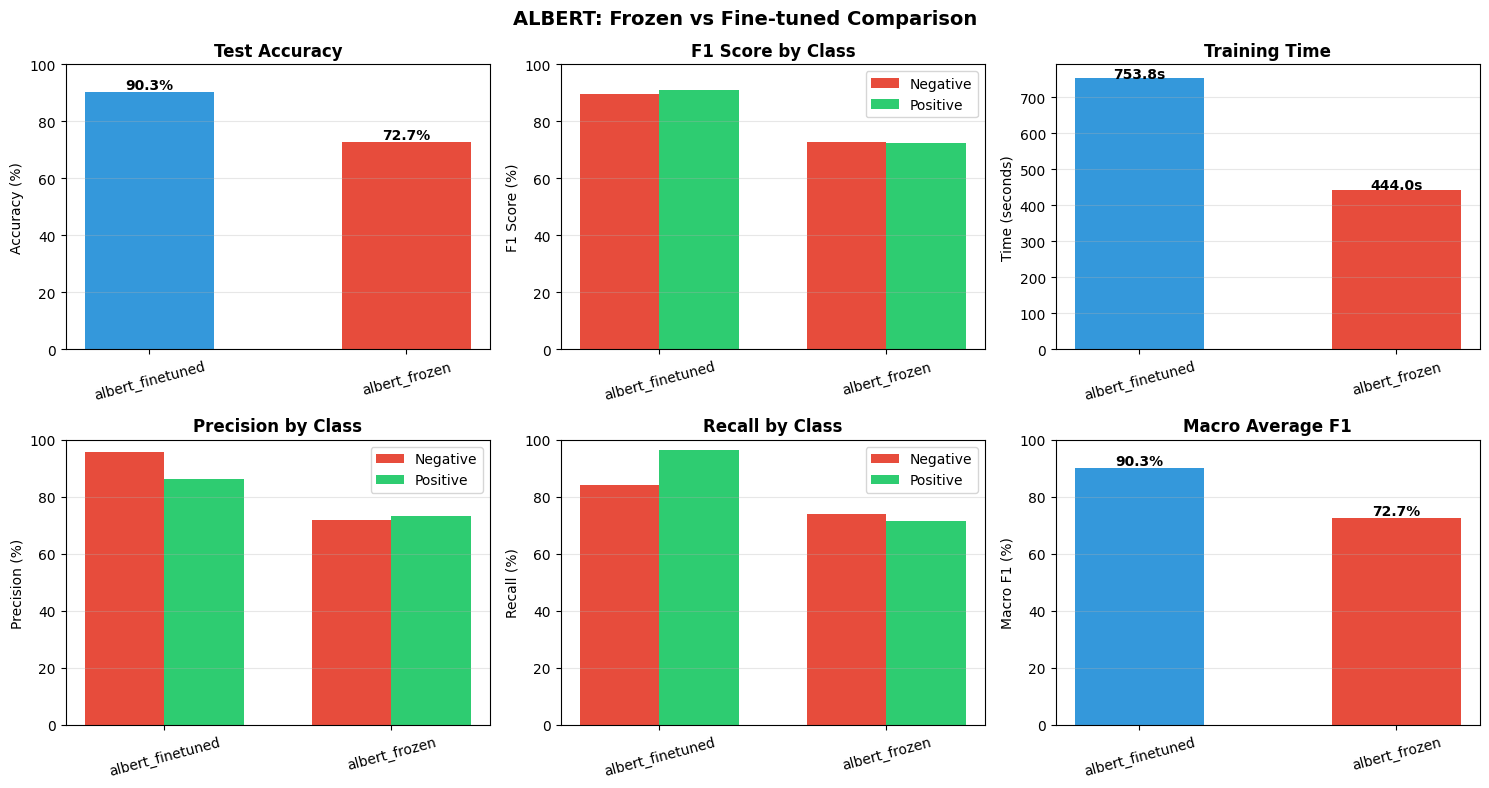


SUMMARY
Best Accuracy: albert_finetuned (90.3%)
Fine-tuning improvement: +17.7%

Chart saved to './albert_comparison.png'


In [29]:
# =========================================================
# COMPARISON CELL - Run this after both experiments
# =========================================================
# First run the cell above with FINE_TUNE_BERT = False
# Then change to FINE_TUNE_BERT = True and run again
# Finally run this cell to see the comparison

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_file = './albert_results.csv'

try:
    comparison_df = pd.read_csv(results_file)
    
    print("=" * 70)
    print("COMPARISON: ALBERT Frozen vs Fine-tuned")
    print("=" * 70)
    
    # Display results table
    display_cols = ['model_type', 'test_accuracy', 'negative_f1', 'positive_f1', 
                    'training_time_sec', 'epochs', 'total_samples']
    available_cols = [col for col in display_cols if col in comparison_df.columns]
    print("\nResults Table:")
    print(comparison_df[available_cols].to_string(index=False))
    
    if len(comparison_df) >= 2:
        # Create comparison plots
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        
        x = np.arange(len(comparison_df))
        width = 0.5
        colors = ['#3498db', '#e74c3c'][:len(comparison_df)]
        
        # Plot 1: Test Accuracy
        bars = axes[0].bar(x, comparison_df['test_accuracy'], width, color=colors)
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_title('Test Accuracy', fontweight='bold')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(comparison_df['model_type'], rotation=15)
        axes[0].set_ylim([0, 100])
        for i, v in enumerate(comparison_df['test_accuracy']):
            axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Plot 2: F1 Scores
        width_small = 0.35
        axes[1].bar(x - width_small/2, comparison_df['negative_f1'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[1].bar(x + width_small/2, comparison_df['positive_f1'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[1].set_ylabel('F1 Score (%)')
        axes[1].set_title('F1 Score by Class', fontweight='bold')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(comparison_df['model_type'], rotation=15)
        axes[1].legend()
        axes[1].set_ylim([0, 100])
        axes[1].grid(axis='y', alpha=0.3)
        
        # Plot 3: Training Time
        bars = axes[2].bar(x, comparison_df['training_time_sec'], width, color=colors)
        axes[2].set_ylabel('Time (seconds)')
        axes[2].set_title('Training Time', fontweight='bold')
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(comparison_df['model_type'], rotation=15)
        for i, v in enumerate(comparison_df['training_time_sec']):
            axes[2].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')
        axes[2].grid(axis='y', alpha=0.3)
        
        # Plot 4: Precision
        axes[3].bar(x - width_small/2, comparison_df['negative_precision'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[3].bar(x + width_small/2, comparison_df['positive_precision'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[3].set_ylabel('Precision (%)')
        axes[3].set_title('Precision by Class', fontweight='bold')
        axes[3].set_xticks(x)
        axes[3].set_xticklabels(comparison_df['model_type'], rotation=15)
        axes[3].legend()
        axes[3].set_ylim([0, 100])
        axes[3].grid(axis='y', alpha=0.3)
        
        # Plot 5: Recall
        axes[4].bar(x - width_small/2, comparison_df['negative_recall'], width_small, 
                    label='Negative', color='#e74c3c')
        axes[4].bar(x + width_small/2, comparison_df['positive_recall'], width_small, 
                    label='Positive', color='#2ecc71')
        axes[4].set_ylabel('Recall (%)')
        axes[4].set_title('Recall by Class', fontweight='bold')
        axes[4].set_xticks(x)
        axes[4].set_xticklabels(comparison_df['model_type'], rotation=15)
        axes[4].legend()
        axes[4].set_ylim([0, 100])
        axes[4].grid(axis='y', alpha=0.3)
        
        # Plot 6: Macro F1
        avg_f1 = (comparison_df['negative_f1'] + comparison_df['positive_f1']) / 2
        bars = axes[5].bar(x, avg_f1, width, color=colors)
        axes[5].set_ylabel('Macro F1 (%)')
        axes[5].set_title('Macro Average F1', fontweight='bold')
        axes[5].set_xticks(x)
        axes[5].set_xticklabels(comparison_df['model_type'], rotation=15)
        axes[5].set_ylim([0, 100])
        for i, v in enumerate(avg_f1):
            axes[5].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
        axes[5].grid(axis='y', alpha=0.3)
        
        plt.suptitle('ALBERT: Frozen vs Fine-tuned Comparison', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./albert_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Summary
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
        best_acc_idx = comparison_df['test_accuracy'].idxmax()
        print(f"Best Accuracy: {comparison_df.loc[best_acc_idx, 'model_type']} ({comparison_df.loc[best_acc_idx, 'test_accuracy']:.1f}%)")
        
        acc_diff = comparison_df.loc[comparison_df['model_type'] == 'albert_finetuned', 'test_accuracy'].values
        acc_frozen = comparison_df.loc[comparison_df['model_type'] == 'albert_frozen', 'test_accuracy'].values
        if len(acc_diff) > 0 and len(acc_frozen) > 0:
            improvement = acc_diff[0] - acc_frozen[0]
            print(f"Fine-tuning improvement: {improvement:+.1f}%")
        
        print(f"\nChart saved to './albert_comparison.png'")
    else:
        print("\n⚠️  Only one experiment found. Run with both FINE_TUNE_BERT=False and FINE_TUNE_BERT=True")
        print("   to see the comparison.")
        
except FileNotFoundError:
    print("No results file found. Run the training cell first.")

# Conclusiones:

En este ejercicio, entrenamos un modelo Albert tanto con los pesos congelados como fine-tuneado. Con el modelo LSTM en un ejercicio anterior, conseguimos una accuracy del 70%, tanto con embeddings aprendidos como con GloVe. El tiempo máximo de entrenamiento para los embeddings aprendidos fue de 1.7 minutos y tomó 6 épocas (con early stopping).

En este caso, hemos entrenado ambos modelos con 5 épocas. El entrenamiento del modelo finetuneado ha tomado 12.5 minutos (4 épocas con early stopping) y hemos tenido que usar una L4 con 24 GB de VRAM para poder entrenarlo con un batch_size de 32. Sin embargo, los resultados son muy buenos, consiguiendo un 90% de accuracy en el conjunto de test, una mejora del 20% respecto al LSTM.

Con respecto al modelo congelado, apenas consigue mejorar los resultados del LSTM, con un 72% de accuracy, tardando el entrenamiento 7 minutos y necesitando 5 épocas (sin llegar al early stopping).

Tras estos resultados, podemos concluir que cuando finetuneamos un modelo para una tarea específica podemos llegar a conseguir resultados muy buenos, aunque siempre hay un trade-off entre el tiempo de entrenamiento y la mayor precisión, que dependiendo del caso y el tamaño del conjunto de entrenamiento, será rentable o no.